# AI Usage Disclosure

I used OpenAI Codex as a support tool during this project.

Codex helped me organize the notebook structure, write and revise Python code for EDA, stationarity checks, ARIMA/SARIMA modeling, residual diagnostics, and forecasting. It also helped me align the project files with the final project requirements.

The AI tool was used for coding assistance, organization, and explanation.

I manually reviewed, edited, and ran the notebook cells. I also checked the dataset preparation, ACF/PACF interpretation, stationarity decisions, model comparison, coefficient interpretation, residual diagnostics, and final conclusions. i also chose the SARIMA orders manually (did not use auto sarima).

The final responsibility for the submitted code, explanations, plots, model choice, and interpretation is mine. I must be able to explain every part of the notebook and the modeling process in the oral mini-defense.


# Time Series Analysis Project: Influenza-Like Illness (ILI)

This project analyzes weekly influenza-like illness (ILI) activity using the **ILINet** dataset exported from the U.S. Centers for Disease Control and Prevention (CDC) FluView system. ILINet collects reports from sentinel healthcare providers and summarizes the percentage of outpatient visits related to influenza-like illness.

The selected data contains observations for **New York state** only. The raw file is reported by epidemiological YEAR and WEEK, covering **week 40 of 2010 through week 20 of 2026**. In this notebook, those year/week fields are normalized into one continuous weekly date index so the data can be analyzed and plotted as a proper time series.

The main feature used in the analysis is %UNWEIGHTED ILI, renamed to ili. This variable represents the percentage of patient visits attributed to influenza-like illness in a given week. Other columns, such as age groups, weighted ILI, provider counts, and total patients, are ignored in the modeling stage because this project focuses on a univariate time series forecasting task.

The goal is to understand the trend, seasonality, stationarity, and autocorrelation structure of weekly ILI activity, then forecast future ILI values using a seasonal ARIMA (SARIMA) model.


## 1. Setup

In [33]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Load the Data

The first line of this CDC FluView export is a title, so the actual CSV header starts on the second line.

In [34]:
DATA_PATH = Path("data/ILINet.csv")

raw_df = pd.read_csv(DATA_PATH, skiprows=1)
raw_df.head()

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,States,New York,2010,40,X,0.262990,X,X,X,X,X,X,37,91,14069
1,States,New York,2010,41,X,0.369729,X,X,X,X,X,X,47,89,12712
2,States,New York,2010,42,X,0.362121,X,X,X,X,X,X,53,95,14636
3,States,New York,2010,43,X,0.358981,X,X,X,X,X,X,53,98,14764
4,States,New York,2010,44,X,0.527357,X,X,X,X,X,X,80,104,15170


In [35]:
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.info()

Rows: 816
Columns: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   REGION TYPE        816 non-null    object 
 1   REGION             816 non-null    object 
 2   YEAR               816 non-null    int64  
 3   WEEK               816 non-null    int64  
 4   % WEIGHTED ILI     816 non-null    object 
 5   %UNWEIGHTED ILI    816 non-null    float64
 6   AGE 0-4            816 non-null    object 
 7   AGE 25-49          816 non-null    object 
 8   AGE 25-64          816 non-null    object 
 9   AGE 5-24           816 non-null    object 
 10  AGE 50-64          816 non-null    object 
 11  AGE 65             816 non-null    object 
 12  ILITOTAL           816 non-null    int64  
 13  NUM. OF PROVIDERS  816 non-null    int64  
 14  TOTAL PATIENTS     816 non-null    int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 95.

## 3. Basic Structure Checks

In [36]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
REGION TYPE,816,1,States,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION,816,1,New York,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,816.0,NaN,NaN,NaN,2018.074755,4.531612,2010.0,2014.0,2018.0,2022.0,2026.0
WEEK,816.0,NaN,NaN,NaN,26.515931,15.216708,1.0,13.0,26.0,40.0,53.0
% WEIGHTED ILI,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
%UNWEIGHTED ILI,816.0,NaN,NaN,NaN,1.937964,1.850052,0.0,0.812601,1.3901,2.421133,14.42
AGE 0-4,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 25-49,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 25-64,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE 5-24,816,1,X,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
summary = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_values": raw_df.isna().sum(),
    "x_placeholders": (raw_df == "X").sum(),
    "unique_values": raw_df.nunique(dropna=False),
})

summary

,dtype,missing_values,x_placeholders,unique_values
REGION TYPE,object,0,0,1
REGION,object,0,0,1
YEAR,int64,0,0,17
WEEK,int64,0,0,53
% WEIGHTED ILI,object,0,816,1
%UNWEIGHTED ILI,float64,0,0,802
AGE 0-4,object,0,816,1
AGE 25-49,object,0,816,1
AGE 25-64,object,0,816,1
AGE 5-24,object,0,816,1


In [38]:
raw_df[["REGION TYPE", "REGION", "YEAR", "WEEK"]].agg(["min", "max", "nunique"])

,REGION TYPE,REGION,YEAR,WEEK
min,States,New York,2010,1
max,States,New York,2026,53
nunique,1,1,17,53


## 4. Clean and Prepare the Weekly ILI Time Series

From this point onward, we keep only the time information and the ILI target. The raw file stores time as `YEAR` and `WEEK`, so we convert those fields into one continuous weekly date index for plotting and later modeling.

In [39]:
ts_df = raw_df[["YEAR", "WEEK", "%UNWEIGHTED ILI"]].copy()

ts_df = ts_df.rename(columns={
    "YEAR": "year",
    "WEEK": "week",
    "%UNWEIGHTED ILI": "ili",
})

ts_df["year"] = pd.to_numeric(ts_df["year"], errors="coerce")
ts_df["week"] = pd.to_numeric(ts_df["week"], errors="coerce")
ts_df["ili"] = pd.to_numeric(ts_df["ili"], errors="coerce")

ts_df = ts_df.dropna(subset=["year", "week", "ili"]).sort_values(["year", "week"]).reset_index(drop=True)

# Normalize the reported year/week fields into one continuous weekly date axis.
# This avoids artificial gaps caused by calendar-year weekday shifts.
first_year = int(ts_df.loc[0, "year"])
first_week = int(ts_df.loc[0, "week"])
first_date = pd.to_datetime(f"{first_year}-01-01") + pd.to_timedelta((first_week - 1) * 7, unit="D")

ts_df["date"] = pd.date_range(start=first_date, periods=len(ts_df), freq="7D")
ts_df = ts_df[["date", "ili"]].set_index("date").asfreq("7D")

ts_df.head()

,ili
date,
2010-10-01,0.262990
2010-10-08,0.369729
2010-10-15,0.362121
2010-10-22,0.358981
2010-10-29,0.527357


In [40]:
print(f"Start date: {ts_df.index.min().date()}")
print(f"End date:   {ts_df.index.max().date()}")
print(f"Weeks:      {len(ts_df):,}")
print(f"Missing ILI values after weekly normalization: {ts_df['ili'].isna().sum():,}")

Start date: 2010-10-01
End date:   2026-05-15
Weeks:      816
Missing ILI values after weekly normalization: 0


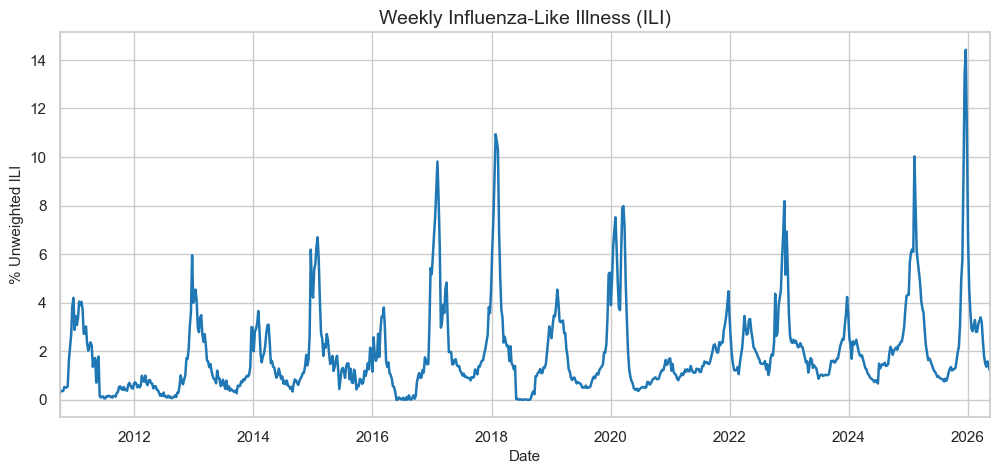

In [41]:
ax = ts_df["ili"].plot(color="#1f77b4", linewidth=1.8)
ax.set_title("Weekly Influenza-Like Illness (ILI)")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
plt.show()

## 5. Project Track and Forecasting Setup

This notebook currently focuses on **SARIMA** forecasting for the weekly ILI series.

Main decisions:
- Target series: weekly `%UNWEIGHTED ILI`, stored as `ili`.
- Forecasting horizon: the final **52 weeks** are held out as the test set.
- Validation rule: chronological train/test split only; no random shuffling.
- Methods covered below: decomposition, stationarity testing, ACF/PACF before and after differencing, SARIMA forecasting, confidence intervals, error metrics, and residual diagnostics.

In [42]:
import subprocess
import sys


try:
    from arch.unitroot import PhillipsPerron
except ModuleNotFoundError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "arch",
        "--trusted-host", "pypi.org",
        "--trusted-host", "files.pythonhosted.org",
    ])
    from arch.unitroot import PhillipsPerron
from scipy import stats as scipy_stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEASONAL_PERIOD = 52
TEST_SIZE = 52

y = ts_df["ili"].copy()
train = y.iloc[:-TEST_SIZE]
test = y.iloc[-TEST_SIZE:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} weeks)")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()} ({len(test)} weeks)")

Training period: 2010-10-01 to 2025-05-16 (764 weeks)
Test period:     2025-05-23 to 2026-05-15 (52 weeks)


## 6. Decomposition

The final project requires separating the series into trend, seasonal, and residual components. Because this is weekly influenza data, a natural seasonal period is 52 weeks.

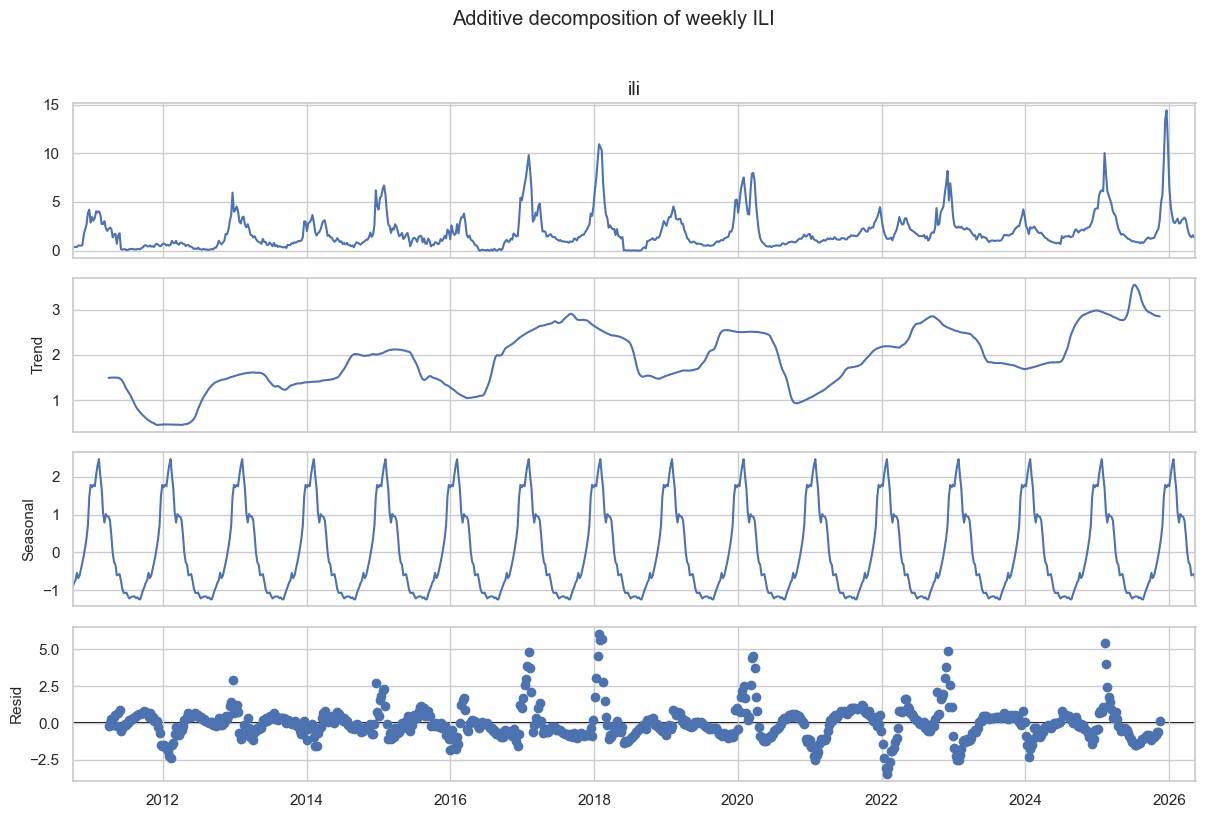

In [43]:
decomposition = seasonal_decompose(y, model="additive", period=SEASONAL_PERIOD)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Additive decomposition of weekly ILI", y=1.02)
plt.tight_layout()
plt.show()

## 7. Stationarity Tests

The final project guidelines require **ADF (Augmented Dickey-Fuller)**. The Week 9 stationarity slides (`time_series_igkle_2026_week9_part1_ver01.pdf`) also mention Phillips-Perron.

Both tests check for a unit root. A small p-value (`< 0.05`) suggests the series is stationary after the tested transformation.

In [44]:
def adf_summary(series, name):
    adf_result = adfuller(series.dropna(), autolag="AIC")
    return pd.Series({
        "series": name,
        "adf_statistic": adf_result[0],
        "adf_p_value": adf_result[1],
        "adf_used_lags": adf_result[2],
        "n_obs": adf_result[3],
        "adf_stationary_at_5pct": adf_result[1] < 0.05,
    })

first_diff = y.diff()
second_diff = y.diff().diff()
seasonal_diff = y.diff(SEASONAL_PERIOD)
seasonal_first_diff = y.diff(SEASONAL_PERIOD).diff()
seasonal_second_diff = y.diff(SEASONAL_PERIOD).diff().diff()

series_to_plot = [
    (y, "Original ILI"),
    (first_diff, "First difference"),
    (second_diff, "Second difference"),
    (seasonal_diff, "Seasonal difference, lag 52"),
    (seasonal_first_diff, "Seasonal + first difference"),
    (seasonal_second_diff, "Seasonal + second difference"),
]

adf_results = pd.DataFrame([
    adf_summary(series, name)
    for series, name in series_to_plot
])

adf_results

,series,adf_statistic,adf_p_value,adf_used_lags,n_obs,adf_stationary_at_5pct
0,Original ILI,-7.128895,3.560215e-10,14,801,True
1,First difference,-11.030675,5.678778e-20,8,806,True
2,Second difference,-14.181537,1.924762e-26,12,801,True
3,"Seasonal difference, lag 52",-5.444172,2.733945e-06,9,754,True
4,Seasonal + first difference,-12.604694,1.705984e-23,8,754,True
5,Seasonal + second difference,-10.919812,1.044946e-19,20,741,True


### Phillips-Perron Test

Phillips-Perron is used as a second unit-root test, based on the Week 9 stationarity slides.

In [45]:
import subprocess
import sys

try:
    from arch.unitroot import PhillipsPerron
except ModuleNotFoundError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "arch",
        "--trusted-host", "pypi.org",
        "--trusted-host", "files.pythonhosted.org",
    ])
    from arch.unitroot import PhillipsPerron

pp_results = []
for name, series in [(name, series) for series, name in series_to_plot]:
    pp_test = PhillipsPerron(series.dropna())
    pp_results.append({
        "series": name,
        "pp_statistic": pp_test.stat,
        "pp_p_value": pp_test.pvalue,
        "pp_stationary_at_5pct": pp_test.pvalue < 0.05,
    })

pp_results = pd.DataFrame(pp_results)
pp_results


,series,pp_statistic,pp_p_value,pp_stationary_at_5pct
0,Original ILI,-5.629311,1.098783e-06,True
1,First difference,-20.438551,0.000000e+00,True
2,Second difference,-91.077412,0.000000e+00,True
3,"Seasonal difference, lag 52",-5.761049,5.671330e-07,True
4,Seasonal + first difference,-23.787657,0.000000e+00,True
5,Seasonal + second difference,-102.810621,0.000000e+00,True


### Visual Stationarity Check

The plots below show each tested series with a rolling mean and rolling standard deviation. A stationary series should not have a clear permanent trend in its average level or variance.

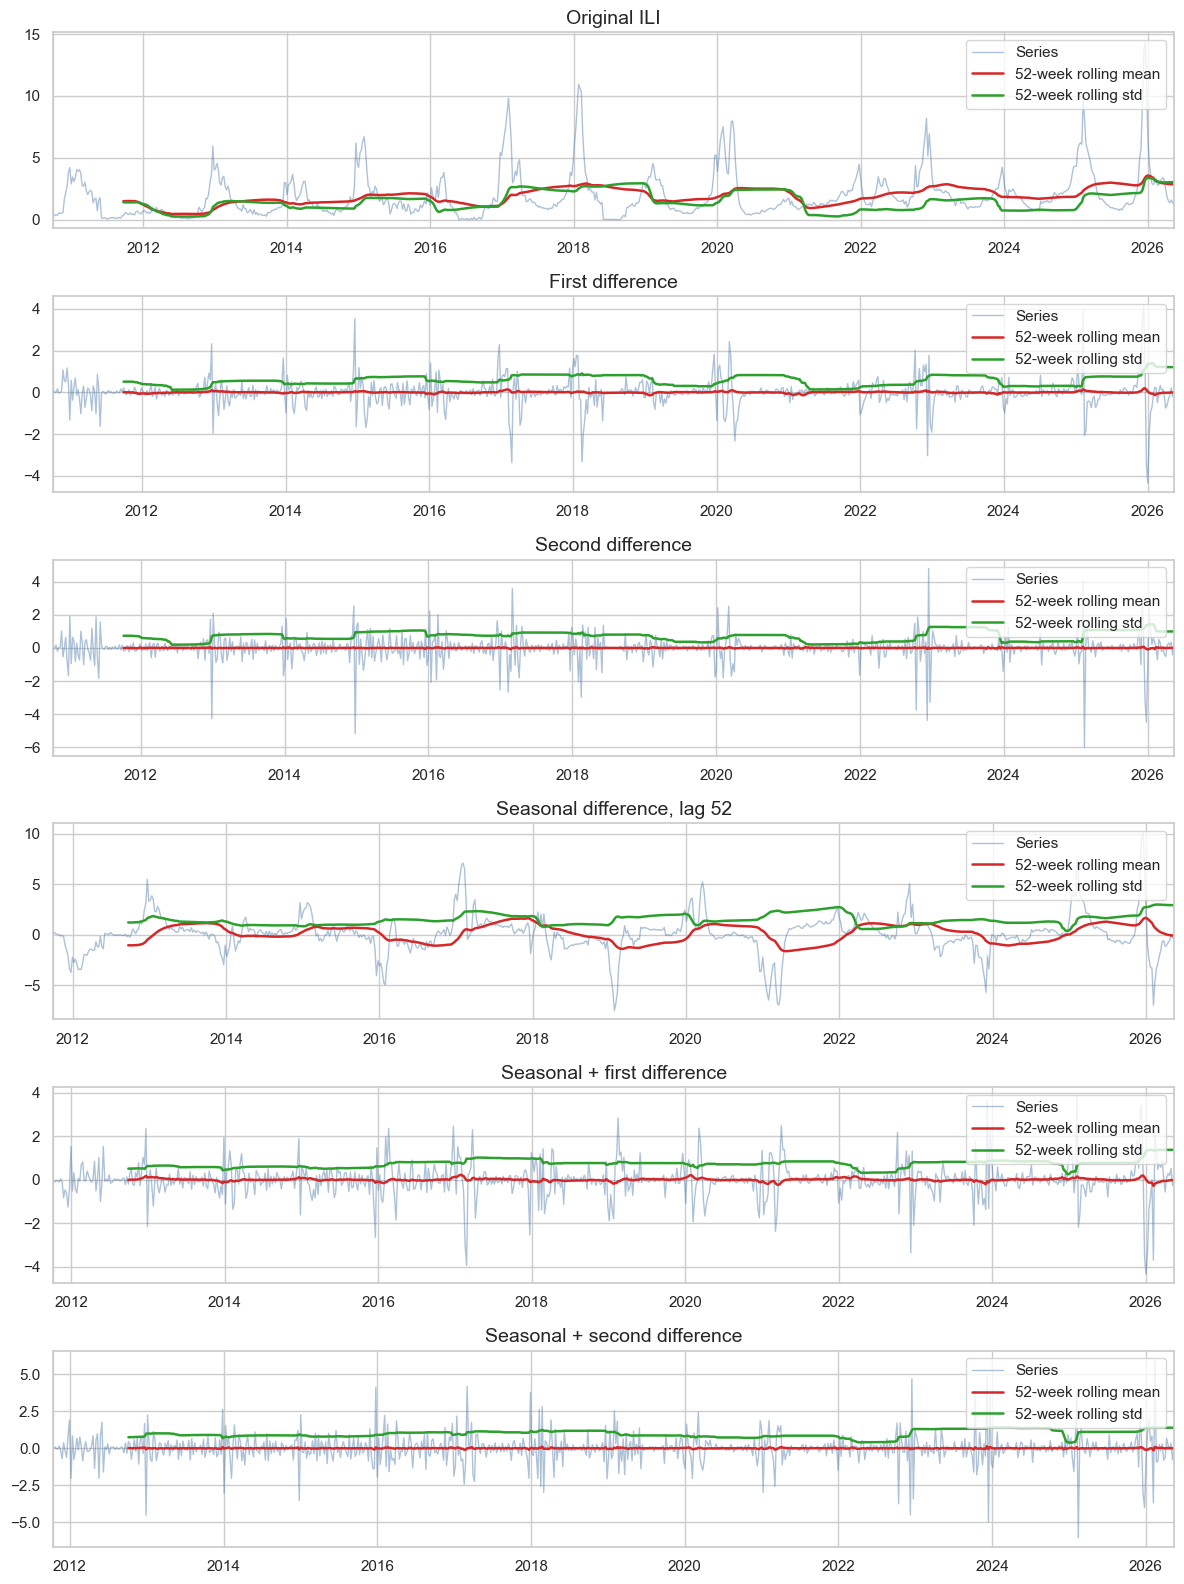

In [46]:
rolling_window = 52

fig, axes = plt.subplots(len(series_to_plot), 1, figsize=(12, 16), sharex=False)

for ax, (series, title) in zip(axes, series_to_plot):
    clean_series = series.dropna()
    rolling_mean = clean_series.rolling(rolling_window).mean()
    rolling_std = clean_series.rolling(rolling_window).std()

    clean_series.plot(ax=ax, color="#4c78a8", linewidth=1, alpha=0.45, label="Series")
    rolling_mean.plot(ax=ax, color="#d62728", linewidth=1.8, label="52-week rolling mean")
    rolling_std.plot(ax=ax, color="#2ca02c", linewidth=1.8, label="52-week rolling std")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Overdifferencing Note

The second-difference series look over-differenced: they are much noisier and lose much of the original structure. Therefore, the next SACF/PACF comparison focuses only on the four main candidates: original, first difference, seasonal difference, and seasonal + first difference.

## 8. ACF / SACF and PACF Before and After Differencing

SACF means sample autocorrelation function. In the Python plots below, `plot_acf` is the SACF/ACF plot. The red dashed lines show approximate 95% confidence bounds.

### Main Series: Time Plot, SACF, and PACF

Each row shows one main transformation: the time plot, its SACF/ACF, and its PACF. Second differencing is omitted here because the visual check above suggests overdifferencing.

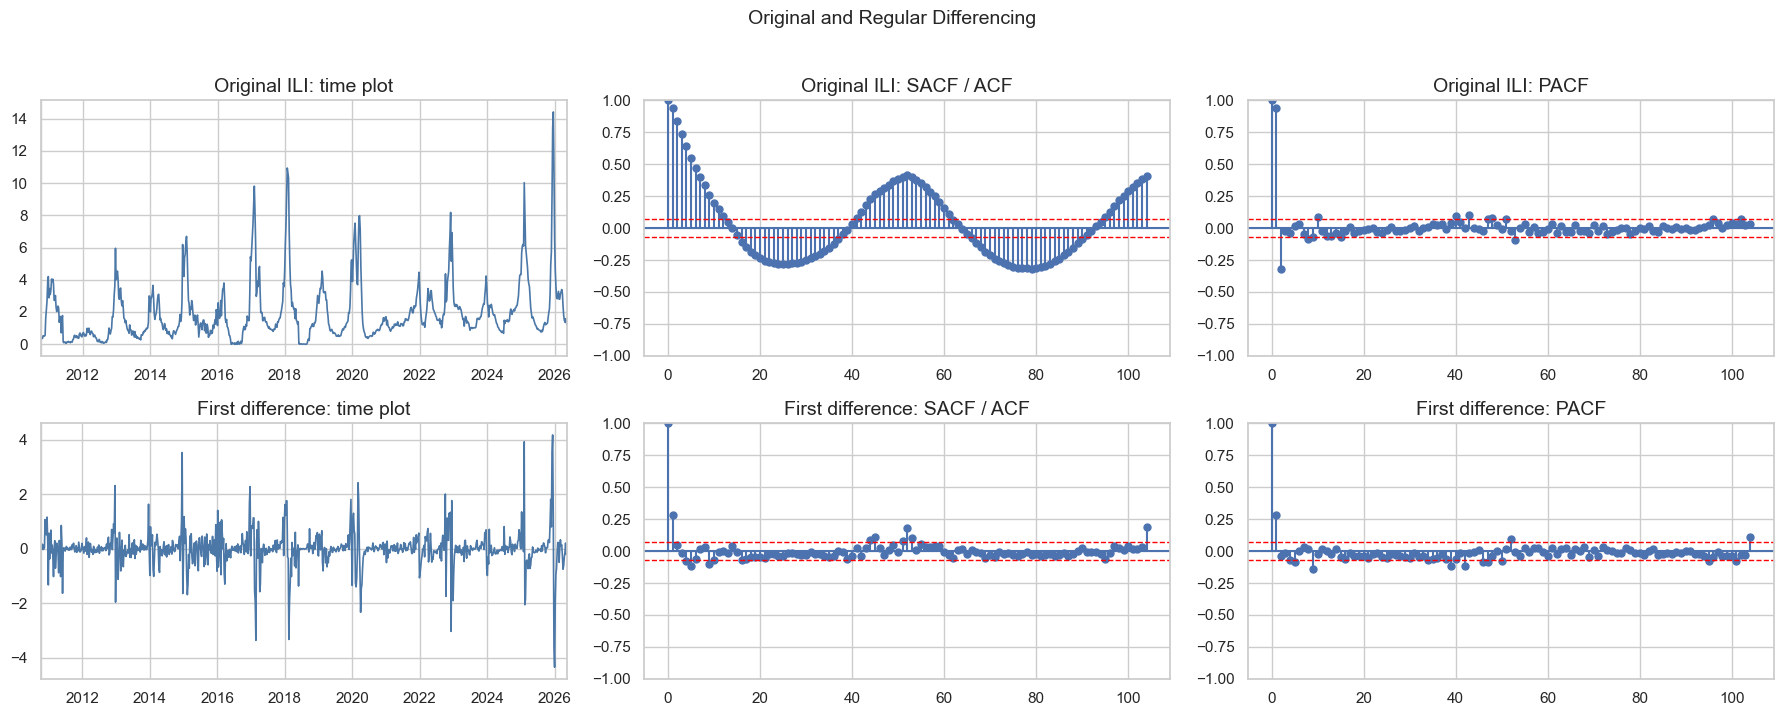

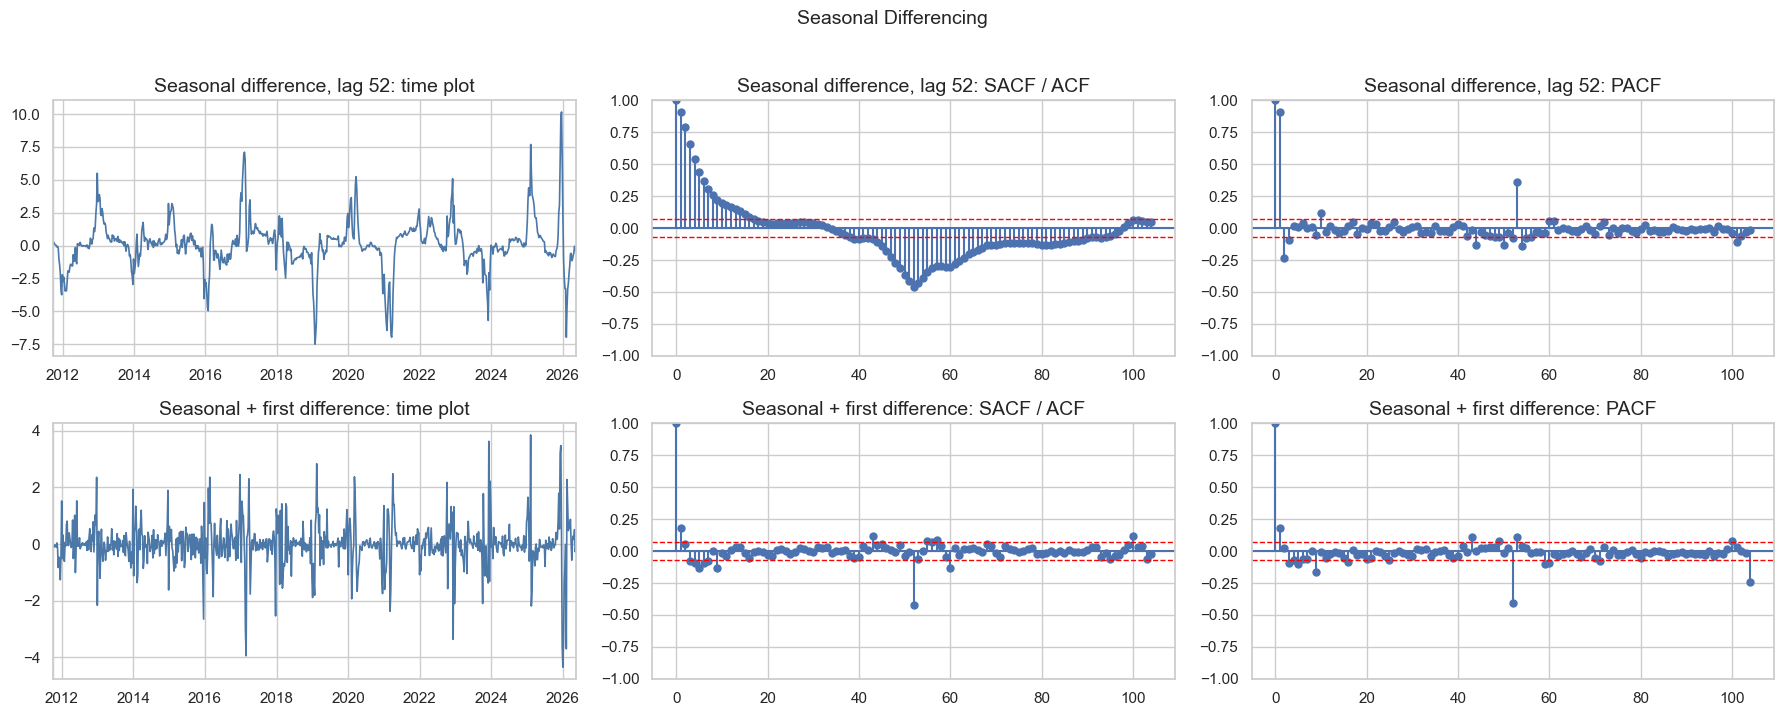

In [47]:
acf_pacf_groups = [
    [
        (y, "Original ILI"),
        (first_diff, "First difference"),
    ],
    [
        (seasonal_diff, "Seasonal difference, lag 52"),
        (seasonal_first_diff, "Seasonal + first difference"),
    ],
]

max_lags = 104

def plot_series_acf_pacf(series_group, figure_title):
    fig, axes = plt.subplots(len(series_group), 3, figsize=(18, 7))
    fig.suptitle(figure_title, fontsize=14, y=1.02)

    for row_idx, (series, title) in enumerate(series_group):
        clean_series = series.dropna()
        ci = 1.96 / np.sqrt(len(clean_series))

        clean_series.plot(ax=axes[row_idx, 0], linewidth=1.2, color="#4c78a8")
        axes[row_idx, 0].set_title(f"{title}: time plot")
        axes[row_idx, 0].set_xlabel("")

        plot_acf(clean_series, lags=max_lags, ax=axes[row_idx, 1], alpha=None)
        axes[row_idx, 1].set_title(f"{title}: SACF / ACF")

        plot_pacf(clean_series, lags=max_lags, ax=axes[row_idx, 2], method="ywm", alpha=None)
        axes[row_idx, 2].set_title(f"{title}: PACF")

        for ax in axes[row_idx, 1:]:
            ax.axhline(ci, color="red", linestyle="--", linewidth=1)
            ax.axhline(-ci, color="red", linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

plot_series_acf_pacf(acf_pacf_groups[0], "Original and Regular Differencing")
plot_series_acf_pacf(acf_pacf_groups[1], "Seasonal Differencing")

## 9. Evaluation Metrics

The project guidelines require MAE, RMSE, and MAPE. MAPE is easy to interpret as a percentage, but it can be unstable when actual values are close to zero.

In [48]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    non_zero = y_true != 0
    return (np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero]).mean()) * 100


def evaluate_forecast(y_true, y_pred, model_name):
    y_pred = pd.Series(y_pred, index=y_true.index)
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred),
    }

## 10. ARIMA and SARIMA Models

We test both non-seasonal ARIMA and seasonal SARIMA candidates. ARIMA candidates are included because the first-difference plots suggest a possible non-seasonal ARMA structure without explicit seasonality. SARIMA candidates are included because the original series has strong yearly seasonality around lag 52. Second differencing is not tested because it may indicate overdifferencing.

### ARIMA and SARIMA Candidate Orders

The following orders are tested based on the SACF/PACF interpretation. For SARIMA models, the seasonal period is `s = 52`.

| Model type | Non-seasonal order `(p,d,q)` | Seasonal order `(P,D,Q,s)` |
|---|---|---|
| ARIMA | `(1,1,0)` | none |
| ARIMA | `(0,1,1)` | none |
| ARIMA | `(1,1,1)` | none |
| ARIMA | `(2,1,1)` | none |
| SARIMA | `(1,0,0)` | `(0,0,1,52)` |
| SARIMA | `(1,0,1)` | `(0,0,1,52)` |
| SARIMA | `(2,0,1)` | `(0,0,1,52)` |
| SARIMA | `(1,0,0)` | `(1,0,0,52)` |
| SARIMA | `(1,0,1)` | `(1,0,0,52)` |
| SARIMA | `(1,0,1)` | `(1,0,1,52)` |
| SARIMA | `(1,0,0)` | `(0,1,1,52)` |
| SARIMA | `(1,0,1)` | `(0,1,1,52)` |
| SARIMA | `(2,0,1)` | `(0,1,1,52)` |
| SARIMA | `(1,0,1)` | `(1,1,0,52)` |
| SARIMA | `(1,0,1)` | `(1,1,1,52)` |
| SARIMA | `(1,1,1)` | `(1,0,0,52)` |

`d=2` models are not tested because the second-difference SACF/PACF suggests possible overdifferencing.

In [49]:
model_candidates = [
    # ARIMA candidates: first differencing, no explicit seasonal component.
    {"model_type": "ARIMA", "order": (1, 1, 0), "seasonal_order": (0, 0, 0, 0)},
    {"model_type": "ARIMA", "order": (0, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    {"model_type": "ARIMA", "order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    {"model_type": "ARIMA", "order": (2, 1, 1), "seasonal_order": (0, 0, 0, 0)},

    # SARIMA d=0 candidates.
    {"model_type": "SARIMA", "order": (1, 0, 0), "seasonal_order": (0, 0, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (0, 0, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (2, 0, 1), "seasonal_order": (0, 0, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 0), "seasonal_order": (1, 0, 0, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (1, 0, 0, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (1, 0, 1, SEASONAL_PERIOD)},

    # SARIMA D=1 candidates.
    {"model_type": "SARIMA", "order": (1, 0, 0), "seasonal_order": (0, 1, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (0, 1, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (2, 0, 1), "seasonal_order": (0, 1, 1, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (1, 1, 0, SEASONAL_PERIOD)},
    {"model_type": "SARIMA", "order": (1, 0, 1), "seasonal_order": (1, 1, 1, SEASONAL_PERIOD)},

    # One mixed comparison candidate.
    {"model_type": "SARIMA", "order": (1, 1, 1), "seasonal_order": (1, 0, 0, SEASONAL_PERIOD)},
]

model_rows = []
model_results = {}

for candidate in model_candidates:
    model_type = candidate["model_type"]
    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]
    if model_type == "ARIMA":
        model_name = f"ARIMA{order}"
    else:
        model_name = f"SARIMA{order}x{seasonal_order}"
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False, maxiter=80, low_memory=True)
        forecast = result.get_forecast(steps=TEST_SIZE).predicted_mean
        row = evaluate_forecast(test, forecast, model_name)
        row["model_type"] = model_type
        row["order"] = order
        row["seasonal_order"] = seasonal_order
        row["AIC"] = result.aic
        row["BIC"] = result.bic
        model_rows.append(row)
        model_results[model_name] = result
    except Exception as exc:
        model_rows.append({
            "model": model_name,
            "model_type": model_type,
            "order": order,
            "seasonal_order": seasonal_order,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE (%)": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "error": str(exc),
        })

model_comparison = pd.DataFrame(model_rows).sort_values("AIC")
# Backward-compatible aliases used by later cells.
sarima_comparison = model_comparison
sarima_results = model_results
model_comparison

,model,MAE,RMSE,MAPE (%),model_type,order,seasonal_order,AIC,BIC
12,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",1.065662,2.446582,24.501609,SARIMA,"(2, 0, 1)","(0, 1, 1, 52)",1187.967355,1210.413379
11,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",1.070822,2.446834,25.207097,SARIMA,"(1, 0, 1)","(0, 1, 1, 52)",1191.589505,1209.546324
14,"SARIMA(1, 0, 1)x(1, 1, 1, 52)",1.069101,2.428217,26.294092,SARIMA,"(1, 0, 1)","(1, 1, 1, 52)",1205.493978,1227.940003
10,"SARIMA(1, 0, 0)x(0, 1, 1, 52)",1.081024,2.444623,26.322310,SARIMA,"(1, 0, 0)","(0, 1, 1, 52)",1208.467053,1221.939224
9,"SARIMA(1, 0, 1)x(1, 0, 1, 52)",1.659732,3.246676,39.667235,SARIMA,"(1, 0, 1)","(1, 0, 1, 52)",1217.060794,1239.887119
8,"SARIMA(1, 0, 1)x(1, 0, 0, 52)",1.801194,3.394655,45.396908,SARIMA,"(1, 0, 1)","(1, 0, 0, 52)",1223.754389,1242.021078
6,"SARIMA(2, 0, 1)x(0, 0, 1, 52)",1.961438,3.539893,50.356408,SARIMA,"(2, 0, 1)","(0, 0, 1, 52)",1231.068847,1253.895171
5,"SARIMA(1, 0, 1)x(0, 0, 1, 52)",1.921921,3.498786,49.581464,SARIMA,"(1, 0, 1)","(0, 0, 1, 52)",1231.630996,1249.892056
15,"SARIMA(1, 1, 1)x(1, 0, 0, 52)",1.458591,2.969237,46.360277,SARIMA,"(1, 1, 1)","(1, 0, 0, 52)",1238.441989,1256.703049
7,"SARIMA(1, 0, 0)x(1, 0, 0, 52)",1.697097,3.297150,43.209658,SARIMA,"(1, 0, 0)","(1, 0, 0, 52)",1241.131430,1254.831448


## 11. Top 3 ARIMA/SARIMA Model Review

We first rank the ARIMA/SARIMA candidates by both AIC and BIC. Then we inspect the top 3 models, their coefficients, and the 95% confidence intervals (`???? ???`). The final model should balance fit, simplicity, forecast error, and significant coefficients.

In [62]:
ranked_sarima = sarima_comparison.dropna(subset=["AIC", "BIC"]).copy()
ranked_sarima["AIC_rank"] = ranked_sarima["AIC"].rank(method="min")
ranked_sarima["BIC_rank"] = ranked_sarima["BIC"].rank(method="min")
ranked_sarima["combined_rank"] = ranked_sarima["AIC_rank"] + ranked_sarima["BIC_rank"]

top3_sarima = ranked_sarima.sort_values(["combined_rank", "AIC", "BIC"]).head(3)
top3_sarima[["model", "MAE", "RMSE", "MAPE (%)", "AIC", "BIC", "AIC_rank", "BIC_rank", "combined_rank"]]

,model,MAE,RMSE,MAPE (%),AIC,BIC,AIC_rank,BIC_rank,combined_rank
12,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",1.065662,2.446582,24.501609,1187.967355,1210.413379,1.0,2.0,3.0
11,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",1.070822,2.446834,25.207097,1191.589505,1209.546324,2.0,1.0,3.0
14,"SARIMA(1, 0, 1)x(1, 1, 1, 52)",1.069101,2.428217,26.294092,1205.493978,1227.940003,3.0,4.0,7.0


In [63]:
top3_coeff_rows = []

for model_name in top3_sarima["model"]:
    result = sarima_results[model_name]
    conf_int = result.conf_int(alpha=0.05)
    for param_name in result.params.index:
        lower = conf_int.loc[param_name].iloc[0]
        upper = conf_int.loc[param_name].iloc[1]
        top3_coeff_rows.append({
            "model": model_name,
            "parameter": param_name,
            "coef": result.params[param_name],
            "std_err": result.bse[param_name],
            "z_stat": result.tvalues[param_name],
            "p_value": result.pvalues[param_name],
            "ci_95_lower": lower,
            "ci_95_upper": upper,
            "ci_excludes_zero": not (lower <= 0 <= upper),
        })

top3_coefficients = pd.DataFrame(top3_coeff_rows)
top3_coefficients

,model,parameter,coef,std_err,z_stat,p_value,ci_95_lower,ci_95_upper,ci_excludes_zero
0,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",ar.L1,1.432050,0.153955,9.301766,1.381326e-20,1.130305,1.733796,True
1,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",ar.L2,-0.504968,0.138795,-3.638220,2.745291e-04,-0.777002,-0.232934,True
2,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",ma.L1,-0.376216,0.167238,-2.249578,2.447574e-02,-0.703997,-0.048435,True
3,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",ma.S.L52,-0.740586,0.037419,-19.791694,3.510404e-87,-0.813926,-0.667246,True
4,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",sigma2,0.340959,0.018942,18.000299,1.937714e-72,0.303833,0.378084,True
5,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",ar.L1,0.881945,0.019918,44.278647,0.000000e+00,0.842906,0.920984,True
6,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",ma.L1,0.170657,0.039709,4.297695,1.725834e-05,0.092829,0.248485,True
7,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",ma.S.L52,-0.749615,0.038149,-19.649837,5.799924e-86,-0.824385,-0.674845,True
8,"SARIMA(1, 0, 1)x(0, 1, 1, 52)",sigma2,0.343314,0.019097,17.977642,2.916347e-72,0.305885,0.380743,True
9,"SARIMA(1, 0, 1)x(1, 1, 1, 52)",ar.L1,0.887836,0.019276,46.058432,0.000000e+00,0.850055,0.925617,True


### Final SARIMA Choice

The final choice uses the top-3 table and coefficient confidence intervals. If two models perform almost the same, the simpler model is preferred according to the parsimony principle from the lectures.

In [65]:
top3_summary = top3_sarima.set_index("model")

candidate_simple = "SARIMA(2, 0, 1)x(0, 1, 1, 52)"
candidate_lowest_aic = top3_sarima.sort_values("AIC").iloc[0]["model"]

chosen_sarima_name = candidate_simple if candidate_simple in top3_summary.index else candidate_lowest_aic
chosen_sarima_result = sarima_results[chosen_sarima_name]

print(f"Lowest AIC model: {candidate_lowest_aic}")
print(f"Chosen final SARIMA model: {chosen_sarima_name}")

Lowest AIC model: SARIMA(2, 0, 1)x(0, 1, 1, 52)
Chosen final SARIMA model: SARIMA(2, 0, 1)x(0, 1, 1, 52)


In [66]:
best_sarima_name = chosen_sarima_name
best_sarima_result = chosen_sarima_result

sarima_forecast_result = best_sarima_result.get_forecast(steps=TEST_SIZE)
sarima_forecast = sarima_forecast_result.predicted_mean
sarima_conf_int = sarima_forecast_result.conf_int()

print(f"Selected SARIMA model: {best_sarima_name}")
best_sarima_result.summary()

Selected SARIMA model: SARIMA(2, 0, 1)x(0, 1, 1, 52)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                ili   No. Observations:                  764
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 52)   Log Likelihood                -588.984
Date:                            Sat, 04 Jul 2026   AIC                           1187.967
Time:                                    16:43:06   BIC                           1210.413
Sample:                                10-01-2010   HQIC                          1196.669
                                     - 05-16-2025                                         
Covariance Type:                           approx                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4321      0.154      9.302      0.000       1.130       1.734
ar.L2         -0.5050      0.139     -3.638      0.000      -0.777      -0.233
ma.L1         -0.3762      0.167     -2.250      0.024      -0.704      -0.048
ma.S.L52      -0.7406      0.037    -19.792      0.000      -0.814      -0.667
sigma2         0.3410      0.019     18.000      0.000       0.304       0.378
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              2967.70
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               1.58   Skew:                             0.77
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

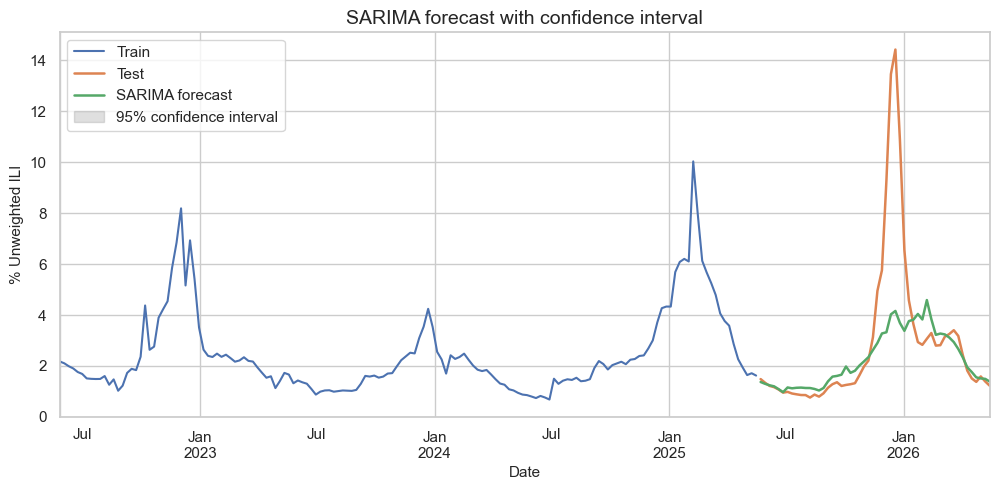

In [67]:
ax = train.iloc[-156:].plot(label="Train", figsize=(12, 5), linewidth=1.5)
test.plot(ax=ax, label="Test", linewidth=1.8)
sarima_forecast.plot(ax=ax, label="SARIMA forecast", linewidth=1.8)
ax.fill_between(
    sarima_conf_int.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    color="gray",
    alpha=0.25,
    label="95% confidence interval",
)
ax.set_title("SARIMA forecast with confidence interval")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()

## 12. SARIMA Test Set Evaluation

The selected SARIMA model is evaluated on the final 52 weeks using MAE, RMSE, and MAPE.

In [68]:
sarima_test_metrics = pd.DataFrame([
    evaluate_forecast(test, sarima_forecast, best_sarima_name)
])

sarima_test_metrics

,model,MAE,RMSE,MAPE (%)
0,"SARIMA(2, 0, 1)x(0, 1, 1, 52)",1.065662,2.446582,24.501609


## 13. SARIMA Coefficient Interpretation

For the mini-defense, focus on the sign and magnitude of AR and MA coefficients:
- Positive AR terms mean high ILI values tend to be followed by high ILI values after the corresponding lag.
- MA terms describe how current forecasts adjust after previous forecast errors.
- Seasonal AR/MA terms describe yearly dependence around lag 52.

### Final Model Coefficient Report

This table follows the lecture-style coefficient report: estimate, standard error, z statistic, p-value, and 95% confidence interval.

In [69]:
final_conf_int = best_sarima_result.conf_int(alpha=0.05)

coefficient_report = pd.DataFrame({
    "coef": best_sarima_result.params,
    "std_err": best_sarima_result.bse,
    "z_stat": best_sarima_result.tvalues,
    "p_value": best_sarima_result.pvalues,
    "ci_95_lower": final_conf_int.iloc[:, 0],
    "ci_95_upper": final_conf_int.iloc[:, 1],
})

coefficient_report["ci_excludes_zero"] = ~((coefficient_report["ci_95_lower"] <= 0) & (coefficient_report["ci_95_upper"] >= 0))
coefficient_report

,coef,std_err,z_stat,p_value,ci_95_lower,ci_95_upper,ci_excludes_zero
ar.L1,1.432050,0.153955,9.301766,1.381326e-20,1.130305,1.733796,True
ar.L2,-0.504968,0.138795,-3.638220,2.745291e-04,-0.777002,-0.232934,True
ma.L1,-0.376216,0.167238,-2.249578,2.447574e-02,-0.703997,-0.048435,True
ma.S.L52,-0.740586,0.037419,-19.791694,3.510404e-87,-0.813926,-0.667246,True
sigma2,0.340959,0.018942,18.000299,1.937714e-72,0.303833,0.378084,True


## 14. Residual Diagnostics

The final project requires checking whether residuals behave like white noise. Following the diagnostics lecture, we inspect standardized residuals, residual ACF, Ljung-Box p-values, QQ plot, and Shapiro-Wilk normality test.

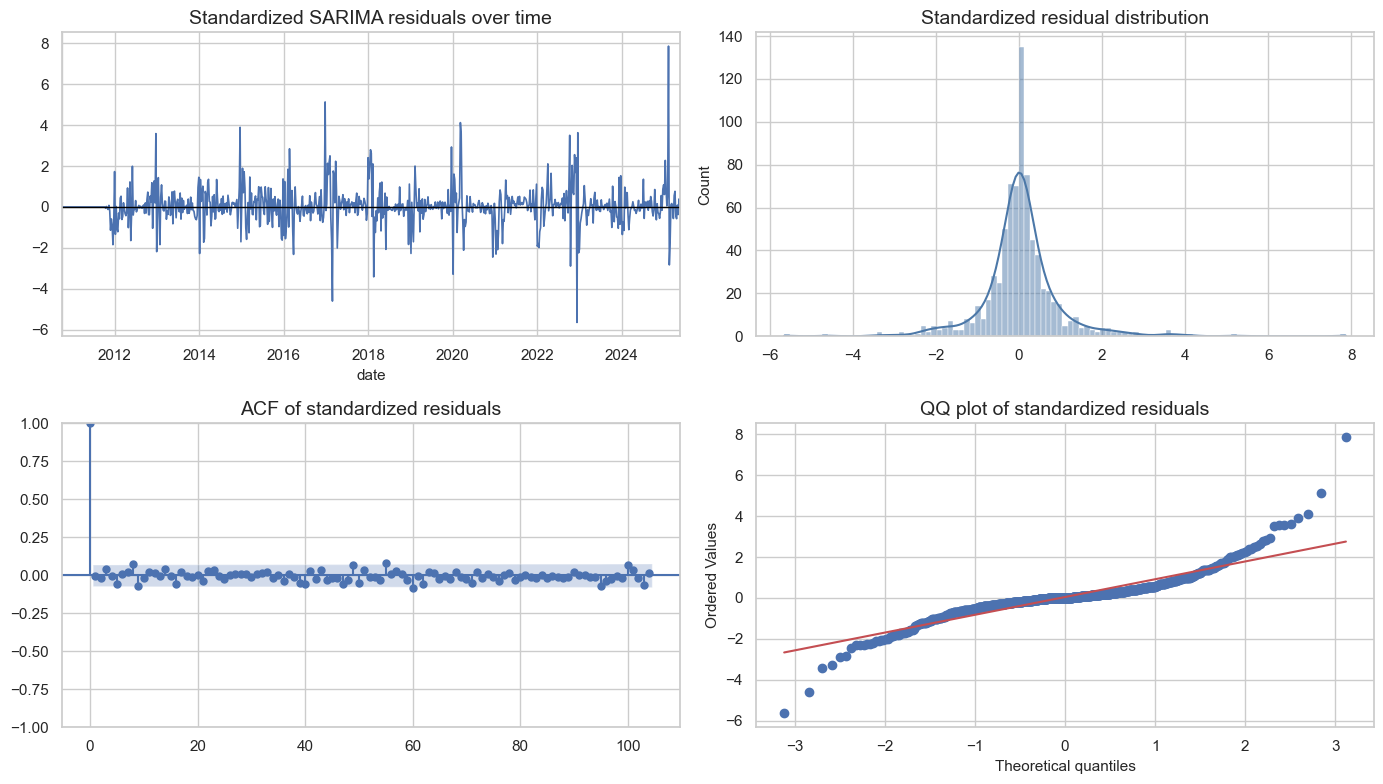

In [70]:
from scipy import stats as scipy_stats

standardized_errors = best_sarima_result.filter_results.standardized_forecasts_error[0]
sarima_residuals = pd.Series(standardized_errors, index=train.index).replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sarima_residuals.plot(ax=axes[0, 0], linewidth=1.2)
axes[0, 0].set_title("Standardized SARIMA residuals over time")
axes[0, 0].axhline(0, color="black", linewidth=1)

sns.histplot(sarima_residuals, kde=True, ax=axes[0, 1], color="#4c78a8")
axes[0, 1].set_title("Standardized residual distribution")

plot_acf(sarima_residuals, lags=104, ax=axes[1, 0])
axes[1, 0].set_title("ACF of standardized residuals")

scipy_stats.probplot(sarima_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ plot of standardized residuals")

plt.tight_layout()
plt.show()

In [71]:
ljung_box = acorr_ljungbox(sarima_residuals, lags=[12, 26, 52], return_df=True)
ljung_box

,lb_stat,lb_pvalue
12,14.170616,0.289946
26,21.166102,0.733340
52,42.216930,0.831614


### Shapiro-Wilk Normality Test

The Shapiro-Wilk test checks whether the standardized residuals are normally distributed.

In [72]:
from scipy import stats as scipy_stats

shapiro_stat, shapiro_pvalue = scipy_stats.shapiro(sarima_residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.3f}")
print(f"Shapiro-Wilk p-value:   {shapiro_pvalue:.4f}")

if shapiro_pvalue >= 0.05:
    print("Shapiro-Wilk result: no strong evidence against normal residuals.")
else:
    print("Shapiro-Wilk result: residuals are not normally distributed.")

if (ljung_box["lb_pvalue"] > 0.05).all():
    print("Ljung-Box result: no strong evidence of residual autocorrelation at the tested lags.")
else:
    print("Ljung-Box result: residual autocorrelation may remain at one or more tested lags.")

Shapiro-Wilk statistic: 0.846
Shapiro-Wilk p-value:   0.0000
Shapiro-Wilk result: residuals are not normally distributed.
Ljung-Box result: no strong evidence of residual autocorrelation at the tested lags.


## 15. Final Forecast Beyond the Observed Data

After evaluating models on the holdout period, we refit the selected SARIMA model on the full available series and forecast the next 52 weeks with confidence intervals.

In [ ]:
selected_order = best_sarima_result.model.order
selected_seasonal_order = best_sarima_result.model.seasonal_order

final_sarima_model = SARIMAX(
    y,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_sarima_result = final_sarima_model.fit(disp=False, maxiter=80, low_memory=True)

future_forecast_result = final_sarima_result.get_forecast(steps=52)
future_forecast = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

forecast_table = pd.DataFrame({
    "forecast_ili": future_forecast,
})

forecast_table.head(10)

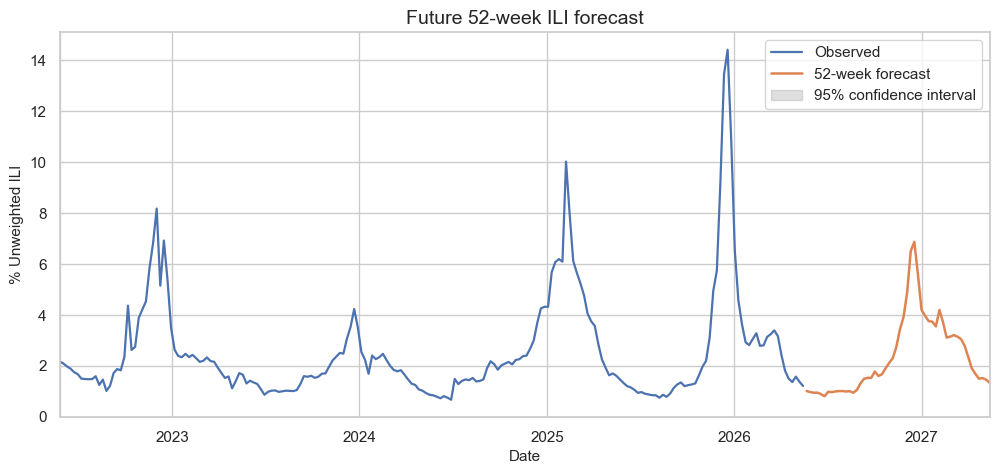

In [ ]:
ax = y.iloc[-208:].plot(label="Observed", figsize=(12, 5), linewidth=1.6)
future_forecast.plot(ax=ax, label="52-week forecast", linewidth=1.8)

ax.set_title("Future 52-week ILI forecast")
ax.set_xlabel("Date")
ax.set_ylabel("% Unweighted ILI")
ax.legend()
plt.show()